# Diagnostics: generalization vs. shortcut learning

Three of the five models hit 100% test accuracy, one hit 99.8%. That's not
proof of overfitting in the classic sense — the test set is genuinely held out
— but it doesn't rule out **shortcut learning**: the model using a
correlated-but-wrong signal (background, lighting, camera angle from a specific
photo session) that happens to line up with class in this dataset.

Two checks, using only what's already trained — no retraining:

1. **Per-session error clustering** — do errors cluster by source photo session
   rather than spreading normally? (Only informative for models that have errors.)
2. **Grad-CAM** — which pixels does each model actually use for its prediction?
   Leaf shape/veins = genuine. Background/soil = shortcut.


In [1]:
import sys, re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from webapp.backend.app.models import MODEL_REGISTRY, CLASSES, is_available, get_model, DEVICE, preprocess

print(f"Device: {DEVICE}")
print(f"Available models: {[k for k in MODEL_REGISTRY if is_available(k)]}")


Device: cuda
Available models: ['custom_cnn', 'convnext_tiny', 'densenet121', 'efficientnet_b0_cbam', 'mobilenetv3_small']


## Part 1 — Per-session error clustering

Rebuilds the exact test-sample order each notebook's `DataLoader` used
(`shuffle=False`, classes iterated in sorted order, files sorted per class —
same as `LeafDataset`), so each row of `predictions.csv` can be matched back to
its source photo session. If a whole session is either all-correct or
all-wrong rather than a normal mix, that suggests the model is keying on
session-level cues rather than per-leaf features.


In [2]:
def session_id(filename):
    """Strip the "_N" crop suffix (e.g. IMG_20240702_162630_1.jpg -> IMG_20240702_162630.jpg)."""
    return re.sub(r"_\d{1,2}\.jpg$", ".jpg", filename, flags=re.IGNORECASE)


test_samples = []
for c in CLASSES:
    for p in sorted((ROOT / "data" / "test" / c).glob("*.jpg")):
        test_samples.append({"class": c, "filename": p.name, "session": session_id(p.name)})

test_df = pd.DataFrame(test_samples)
session_sizes = test_df.groupby("session").size()
print(f"Test set: {len(test_df)} images across {test_df['session'].nunique()} source-photo sessions")
print(f"Sessions with >1 test image: {(session_sizes > 1).sum()} / {len(session_sizes)}")


Test set: 543 images across 279 source-photo sessions
Sessions with >1 test image: 181 / 279


In [3]:
RESULTS_DIRS = {
    "custom_cnn":           "cnn_results",
    "convnext_tiny":        "convnext_tiny_results",
    "densenet121":          "densenet121_results",
    "efficientnet_b0_cbam": "efficientnet_b0_cbam_results",
    "mobilenetv3_small":    "mobilenetv3_small_results",
}
PRED_FILES = {
    "custom_cnn": "predictions_cnn.csv",
    **{k: "predictions.csv" for k in RESULTS_DIRS if k != "custom_cnn"},
}

for key, results_dir in RESULTS_DIRS.items():
    label = MODEL_REGISTRY[key]["label"]
    if not is_available(key):
        print(f"=== {label}: not trained, skipping ===\n")
        continue

    preds = pd.read_csv(ROOT / results_dir / PRED_FILES[key])
    assert len(preds) == len(test_df), f"{key}: sample count mismatch — test set changed since training?"
    assert (preds["True Label"].values == test_df["class"].values).all(), \
        f"{key}: row order mismatch between predictions.csv and rebuilt test set!"

    merged = pd.concat([test_df.reset_index(drop=True), preds[["Correct"]]], axis=1)
    n_errors = int((merged["Correct"] == 0).sum())

    print(f"=== {label} ===")
    print(f"Errors: {n_errors} / {len(merged)}")

    if n_errors == 0:
        print("  No errors on the test set — per-session error clustering has no signal here.\n"
              "  (Can't tell shortcut-learning from genuine accuracy without any mistakes to look at —\n"
              "  Grad-CAM below is the more useful check for this model.)\n")
        continue

    session_stats = merged.groupby("session")["Correct"].agg(["sum", "count"])
    multi         = session_stats[session_stats["count"] > 1]
    mixed         = multi[(multi["sum"] > 0) & (multi["sum"] < multi["count"])]
    uniform_wrong = multi[multi["sum"] == 0]

    print(f"  Multi-image sessions in test set: {len(multi)}")
    print(f"  Mixed (some right, some wrong):   {len(mixed)}")
    print(f"  Uniformly wrong (whole session missed): {len(uniform_wrong)}")
    if len(uniform_wrong) > 0:
        print(f"  -> sessions missed entirely: {list(uniform_wrong.index)}")
    print()


=== Custom 6-Conv CNN ===
Errors: 20 / 543
  Multi-image sessions in test set: 181
  Mixed (some right, some wrong):   3
  Uniformly wrong (whole session missed): 3
  -> sessions missed entirely: ['IMG_20240702_174250.jpg', 'IMG_20240710_170240.jpg', 'IMG_20240710_170250.jpg']

=== ConvNeXt-Tiny ===
Errors: 0 / 543
  No errors on the test set — per-session error clustering has no signal here.
  (Can't tell shortcut-learning from genuine accuracy without any mistakes to look at —
  Grad-CAM below is the more useful check for this model.)

=== DenseNet121 ===
Errors: 0 / 543
  No errors on the test set — per-session error clustering has no signal here.
  (Can't tell shortcut-learning from genuine accuracy without any mistakes to look at —
  Grad-CAM below is the more useful check for this model.)

=== EfficientNet-B0 + CBAM ===
Errors: 0 / 543
  No errors on the test set — per-session error clustering has no signal here.
  (Can't tell shortcut-learning from genuine accuracy without any m

## Part 2 — Grad-CAM

Highlights which pixels most influenced each model's predicted class, via the
gradient of the predicted class score with respect to the last convolutional
feature map (before global pooling), upsampled back onto the image. Green
title = correct prediction, red = incorrect. One representative image per
class, same 8 images across all 5 models for direct comparison.


In [4]:
class GradCAM:
    """Grad-CAM via retain_grad() on a forward-hook-captured activation, rather
    than register_full_backward_hook — some architectures (DenseNet121) apply
    an in-place op immediately after the target layer, which the backward-hook
    variant conflicts with (autograd forbids in-place modification of a view
    created by a custom backward Function)."""
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.fwd = target_layer.register_forward_hook(self._save_activation)

    def _save_activation(self, module, inputs, output):
        output.retain_grad()
        self.activations = output

    def __call__(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = int(output.argmax(dim=1).item())
        output[0, class_idx].backward()

        gradients  = self.activations.grad[0]        # (C, H, W)
        activation = self.activations.detach()[0]    # (C, H, W)
        weights = gradients.mean(dim=(1, 2))
        cam = torch.einsum("c,chw->hw", weights, activation)
        cam = F.relu(cam)
        cam = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy(), class_idx

    def remove(self):
        self.fwd.remove()


# Last conv feature map (pre-global-pool) for each architecture
TARGET_LAYER = {
    "custom_cnn":           lambda m: m.conv6,
    "convnext_tiny":        lambda m: m.features,
    "densenet121":          lambda m: m.features,
    "efficientnet_b0_cbam": lambda m: m.cbam,
    "mobilenetv3_small":    lambda m: m.features,
}


def overlay_cam(pil_image, cam, alpha=0.45):
    img  = np.array(pil_image.resize((224, 224))).astype(np.float32) / 255.0
    heat = Image.fromarray((cam * 255).astype(np.uint8)).resize((224, 224), Image.BICUBIC)
    heat = plt.get_cmap("inferno")(np.array(heat) / 255.0)[..., :3]
    return np.clip((1 - alpha) * img + alpha * heat, 0, 1)


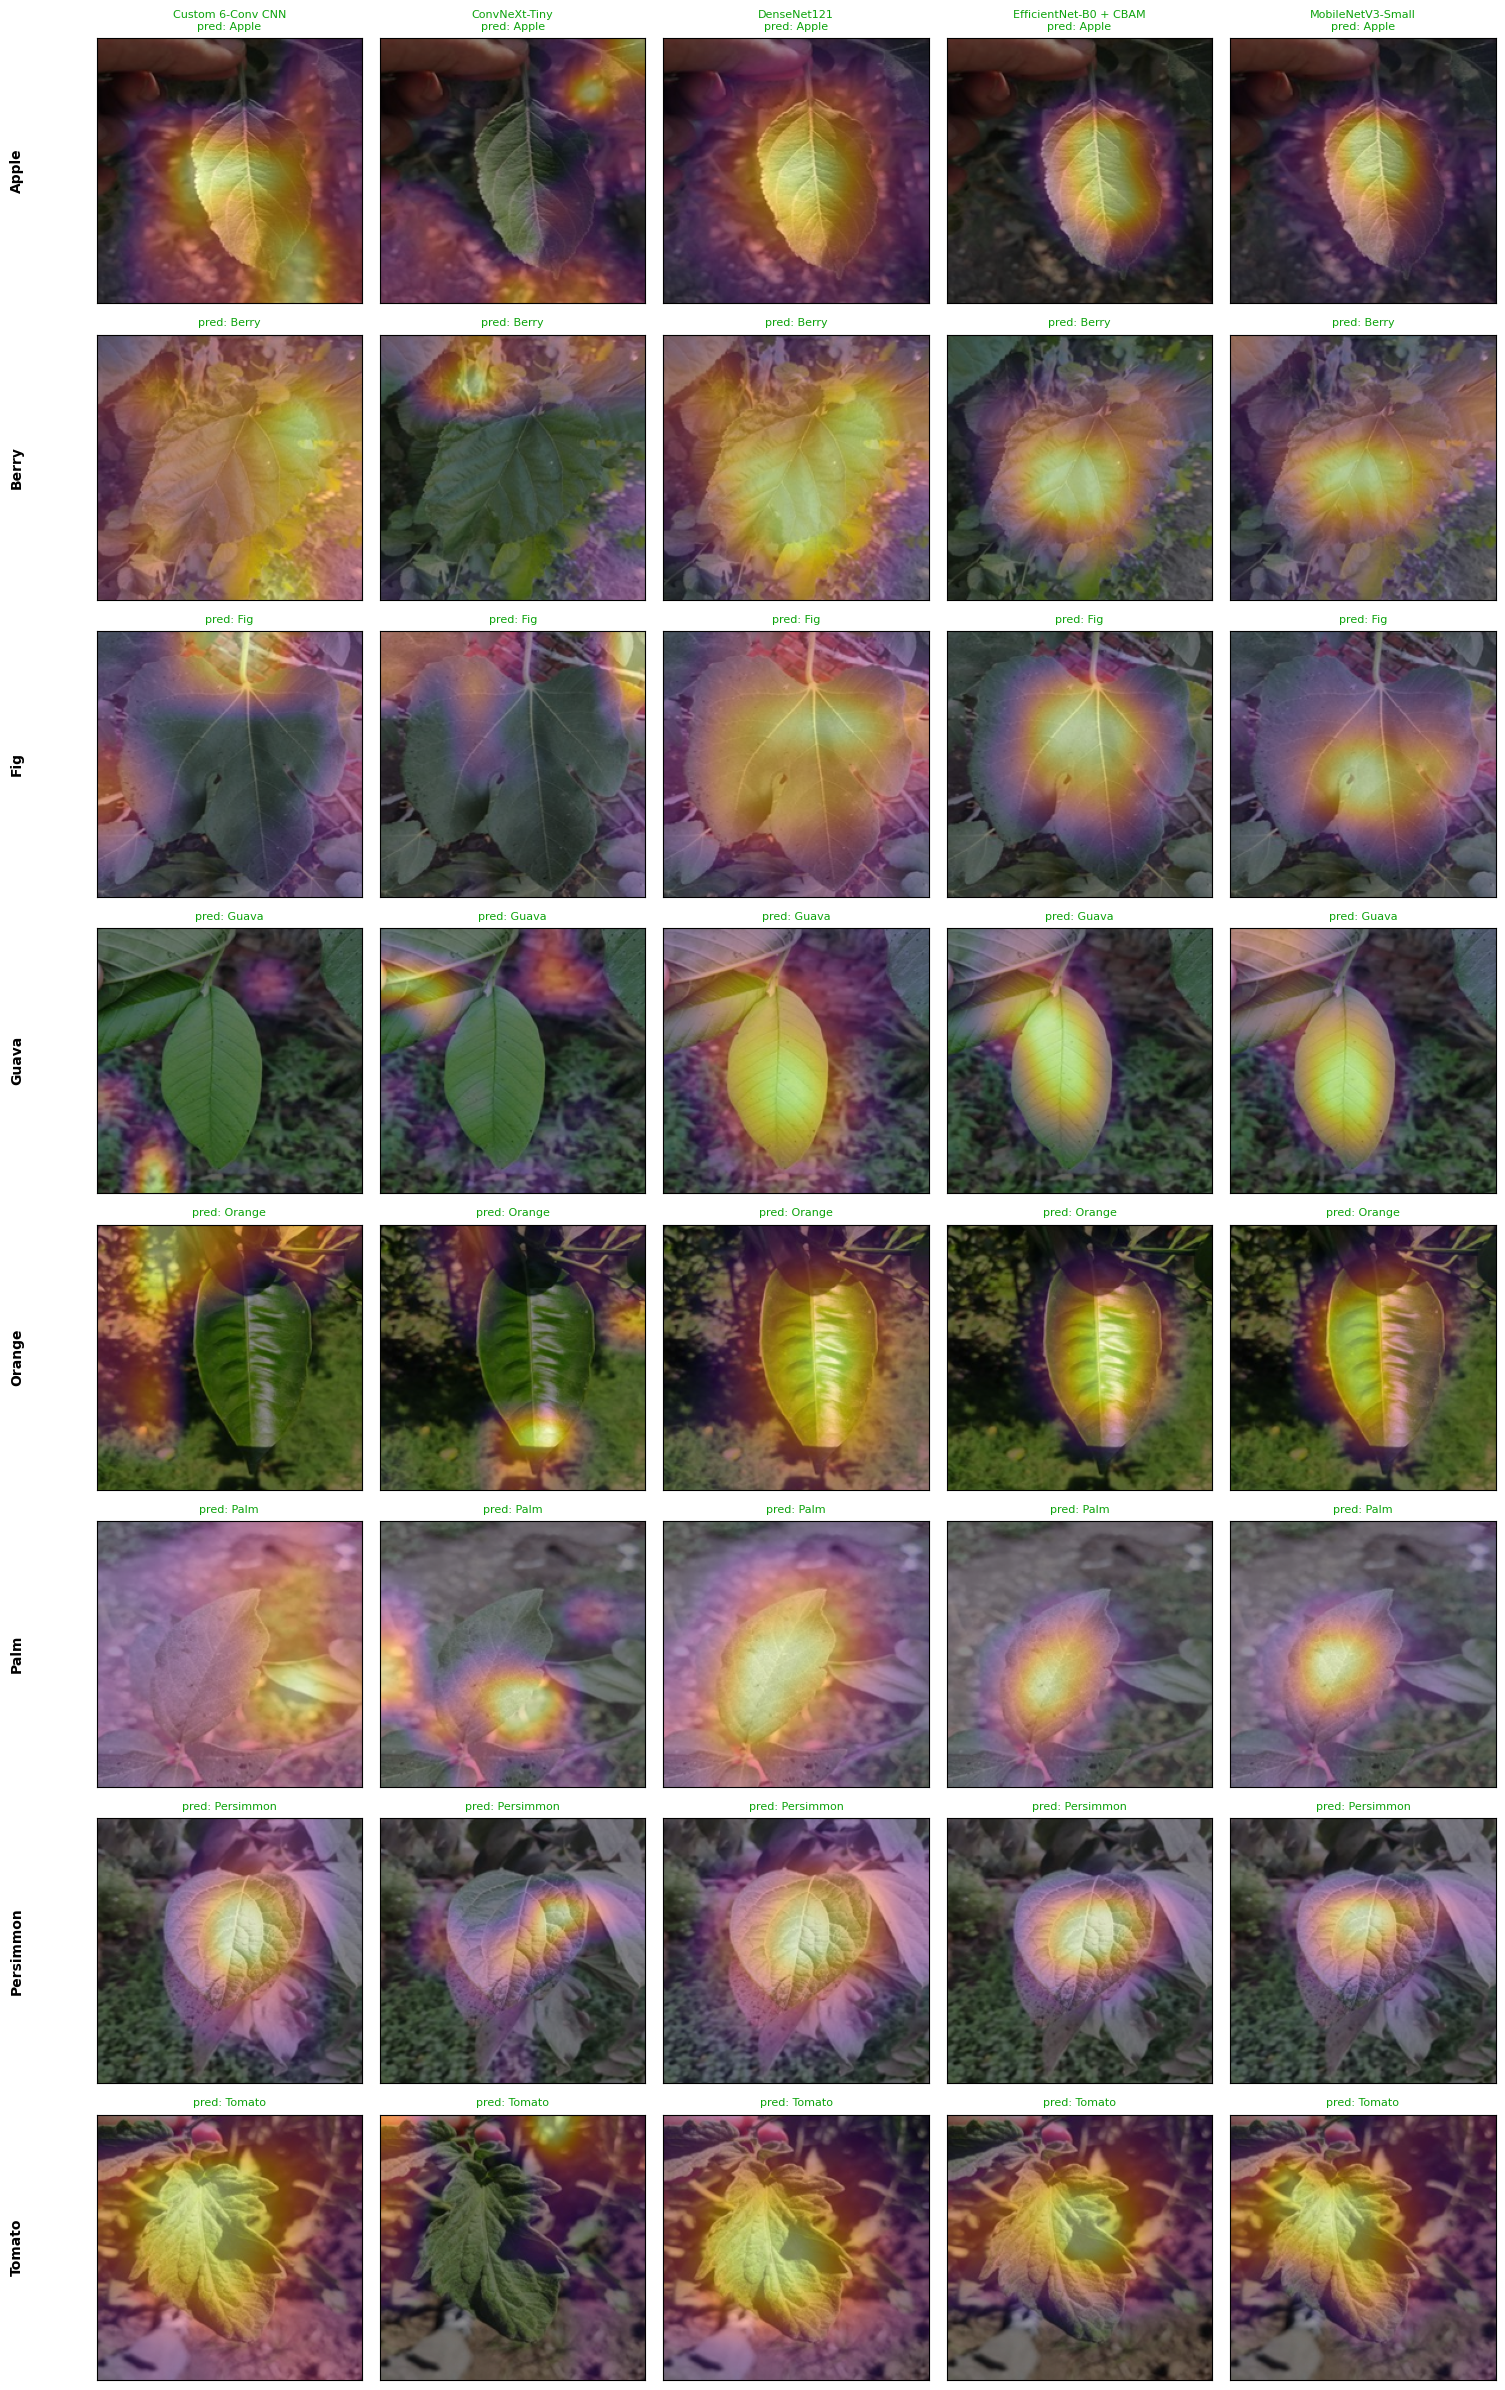

In [5]:
sample_paths = {c: sorted((ROOT / "data" / "test" / c).glob("*.jpg"))[0] for c in CLASSES}
available_models = [k for k in MODEL_REGISTRY if is_available(k)]

fig, axes = plt.subplots(len(CLASSES), len(available_models),
                          figsize=(3 * len(available_models), 3 * len(CLASSES)))

for row, cls in enumerate(CLASSES):
    pil_img = Image.open(sample_paths[cls]).convert("RGB")
    tensor  = preprocess(pil_img).to(DEVICE)

    for col, key in enumerate(available_models):
        model  = get_model(key)
        gradcam = GradCAM(model, TARGET_LAYER[key](model))
        cam, pred_idx = gradcam(tensor)
        gradcam.remove()

        pred_cls = CLASSES[pred_idx]
        ax = axes[row, col]
        ax.imshow(overlay_cam(pil_img, cam))
        ax.set_xticks([]); ax.set_yticks([])
        title = f"pred: {pred_cls}"
        if row == 0:
            title = f"{MODEL_REGISTRY[key]['label']}\n{title}"
        ax.set_title(title, fontsize=8, color=("#0ca30c" if pred_cls == cls else "#d03b3b"))
        if col == 0:
            ax.text(-0.3, 0.5, cls, fontsize=10, fontweight="bold", rotation=90,
                     va="center", ha="center", transform=ax.transAxes)

plt.tight_layout()
plt.savefig(ROOT / "diagnostics_gradcam_grid.png", dpi=150)
plt.show()


### Bonus: EfficientNet-B0 + CBAM's own attention map

CBAM's spatial-attention output isn't gradient-derived like Grad-CAM — it's
literally the sigmoid mask the model learned to multiply its features by. A
second, independent view of where that model is "looking."


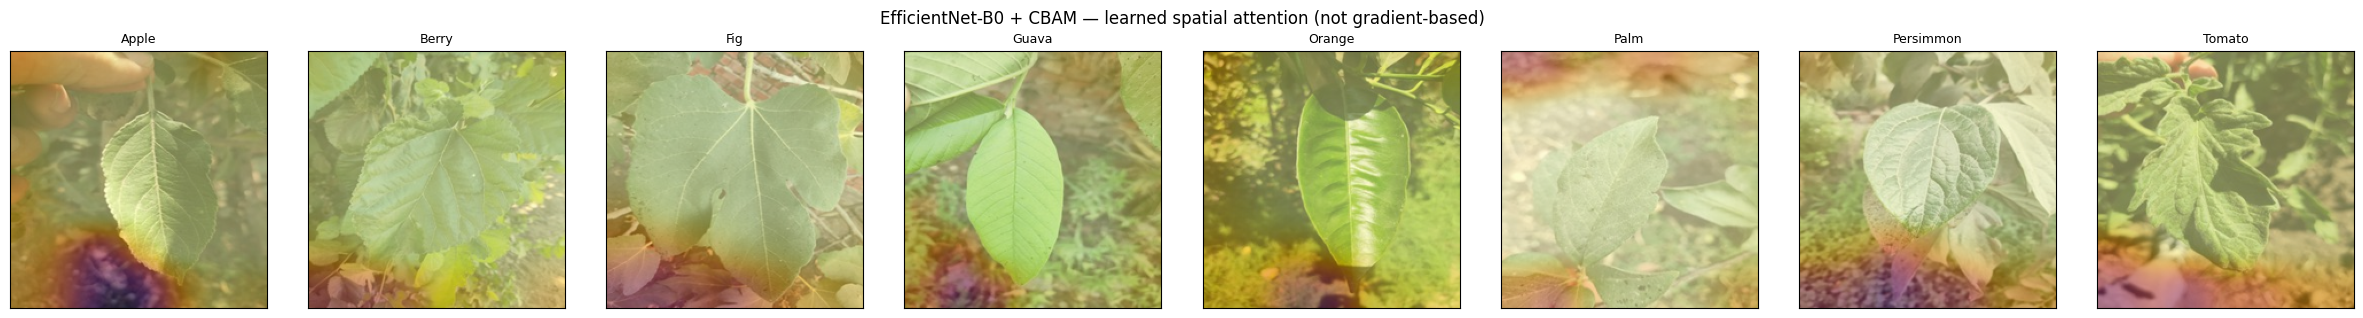

In [6]:
if is_available("efficientnet_b0_cbam"):
    model = get_model("efficientnet_b0_cbam")
    captured = {}

    def _hook(module, inputs, output):
        captured["attn"] = output.detach()

    handle = model.cbam.spatial_attention.register_forward_hook(_hook)

    fig, axes = plt.subplots(1, len(CLASSES), figsize=(3 * len(CLASSES), 3.2))
    with torch.no_grad():
        for col, cls in enumerate(CLASSES):
            pil_img = Image.open(sample_paths[cls]).convert("RGB")
            tensor  = preprocess(pil_img).to(DEVICE)
            _ = model(tensor)
            attn = captured["attn"][0, 0].cpu().numpy()
            axes[col].imshow(overlay_cam(pil_img, attn))
            axes[col].set_xticks([]); axes[col].set_yticks([])
            axes[col].set_title(cls, fontsize=9)

    handle.remove()
    plt.suptitle("EfficientNet-B0 + CBAM — learned spatial attention (not gradient-based)")
    plt.tight_layout()
    plt.savefig(ROOT / "diagnostics_cbam_attention.png", dpi=150)
    plt.show()
else:
    print("EfficientNet-B0 + CBAM not trained — skipping.")


## Reading the results

- **Part 1**: if any model has errors, check whether "uniformly wrong" sessions
  appear — that's the stronger red flag than "mixed" sessions (mixed suggests
  ordinary per-image difficulty; uniform suggests a session-level cue).
- **Part 2**: look at whether the heatmap sits on the leaf (venation, margin,
  shape) or spills onto background/soil/stems. Consistent leaf-focus across
  classes and models is the best evidence available here that these aren't
  pure background shortcuts — but the only fully conclusive test is still new
  photos from a different session (see README "Results" caveat).
